**Lab2-DL: E2-emotions-training.ipynb** (BMED365) | Priority: 3 (optional)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/BMED365-2026/blob/main/Lab2-DL/notebooks/E2-emotions-training.ipynb)

# 😊 E2: CNN Classification of Facial Expressions - Part 2 (Training)

Updated: 2025-12-26, 2026-01-15 A. Lundervold

This notebook is **Part 2** of our emotion recognition experiment. 


## Dataset
We use the **FER2013** (Facial Expression Recognition 2013) dataset with <strike>7</strike> 6 emotion classes:
- **<strike>Anger</strike>** - **this is empty in FER2013**
- 🤢 **Disgust**
- 😨 **Fear**
- 😊 **Happy**
- 😢 **Sad**
- 😲 **Surprise**
- 😐 **Neutral**

We build on the model from Part 1 and focus on:

## 🎯 Learning Objectives

By the end of this notebook, you will be able to:

| Objective | Description |
|-----------|-------------|
| **Train emotion classifier** | Run full training loop with monitoring and checkpointing |
| **Evaluate model performance** | Use confusion matrix, per-class metrics, and confidence analysis |
| **Analyze class imbalance** | Understand why some emotions are harder to classify |
| **Apply explainability** | Visualize what the model "sees" using Grad-CAM |
| **Understand EU AI Act** | Know the regulatory requirements for emotion AI systems |
| **Consider ethics** | Reason about bias, privacy, and responsible deployment |

### What We Will Cover
- **Visual inspection** of the FER2013 dataset
- **Model training** and optimization
- **Evaluation and visualization** of results
- **CAM/Grad-CAM** for explainable AI
- **Medical applications** and comparison with Kaggle leaderboard
- **Ethical discussions** about bias and privacy

## Prerequisites
This notebook assumes you have run **Part 1** (`E1-emotions-building.ipynb`) and have:
- Downloaded and organized the FER2013 dataset
- Defined the `EmotionNet` model
- Created data loaders

---

### But first: 🔧 Environment setup - code should work both locally and in Google Colab

In [1]:
import sys
import subprocess
import os

# Check if we are running in Google Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("🚀 Running in Google Colab")
else:
    print("💻 Running in local environment")

💻 Running in local environment


In [2]:
if IN_COLAB:
    # Go to root folder
    os.chdir('/content')
    
    # Check current folder
    print(f"Current folder: {os.getcwd()}")
    
    # Check if the folder already exists
    if os.path.exists('BMED365-2026/Lab2-DL'):
        print("✅ BMED365-2026/Lab2-DL folder already exists!")
        
        # Check the contents
        print("\n📁 Contents of BMED365-2026/Lab2-DL folder:")
        try:
            result = subprocess.run(['ls', '-la', 'BMED365-2026/Lab2-DL'], 
                                  capture_output=True, text=True, check=True)
            print(result.stdout)
        except subprocess.CalledProcessError as e:
            print(f"❌ Could not list contents: {e}")
        
        # Check if it is a git repository
        if os.path.exists('BMED365-2026/.git'):
            print("\n✅ This is a git repository!")
            
            # Go into the folder and update
            os.chdir('BMED365-2026')
            print(f"📁 Changed to: {os.getcwd()}")
            
            # Try to update the repository
            try:
                result = subprocess.run(['git', 'pull'], 
                                      capture_output=True, text=True, check=True)
                print("✅ Repository updated!")
                print(result.stdout)
            except subprocess.CalledProcessError as e:
                print(f"⚠️ Could not update repository: {e}")
                print("But the folder exists and can be used!")
        else:
            print("⚠️ This does not look like a git repository")
            
    else:
        print("📂 Folder does not exist - trying git clone...")
        try:
            result = subprocess.run(['git', 'clone', 'https://github.com/arvidl/BMED365-2026.git'], 
                                  capture_output=True, text=True, check=True)
            print("✅ Repository cloned successfully!")
            print(result.stdout)
        except subprocess.CalledProcessError as e:
            print(f"❌ Git clone failed: {e}")
            print(f"Error output: {e.stderr}")

## 1. Imports and Setup

In [3]:
# Imports and setup with error handling
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import os
import random
import requests
import zipfile
from PIL import Image
import cv2
from tqdm import tqdm
import warnings
import pickle
from pathlib import Path
import time
import json
from datetime import datetime
warnings.filterwarnings('ignore')

# ============================================================
# REPRODUCIBILITY SETTINGS
# ============================================================
# Set a fixed random seed for all random number generators
RANDOM_SEED = 42

def set_seed(seed=RANDOM_SEED):
    """
    Set random seeds for reproducibility across all libraries.
    This ensures the same results on each run.
    """
    # Python's built-in random
    random.seed(seed)
    
    # NumPy
    np.random.seed(seed)
    
    # PyTorch
    torch.manual_seed(seed)
    
    # PyTorch CUDA (GPU)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # For multi-GPU
        
        # Make cuDNN deterministic (may slow down training slightly)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    
    # Set environment variable for hash seed (Python hash randomization)
    os.environ['PYTHONHASHSEED'] = str(seed)

# Apply reproducibility settings
set_seed(RANDOM_SEED)
print(f"🎲 Random seed set to {RANDOM_SEED} for reproducibility")

# ============================================================
# DEVICE CONFIGURATION
# ============================================================
# Check if GPU or MPS is available and set device
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f'🚀 GPU available: {torch.cuda.get_device_name(0)}')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    print('🍎 Apple Silicon MPS available')
else:
    device = torch.device('cpu')
    print('💻 Using CPU')

print(f'Using device: {device}')

🎲 Random seed set to 42 for reproducibility
🍎 Apple Silicon MPS available
Using device: mps


In [4]:
def fetch_fer2013_dataset():
    """
    Fetch FER2013 dataset from Kaggle (if not already downloaded)
    """
    print("📥 Fetching FER2013 dataset")
    print("=" * 50)
    
    data_dir = Path("../data/emotions/FER2013")
    data_dir.mkdir(parents=True, exist_ok=True)
    
    # Check if data already exists
    existing_images = list(data_dir.glob("**/*.png")) + list(data_dir.glob("**/*.jpg"))
    
    if existing_images:
        print(f"✅ Data already exists: {len(existing_images)} images")
        return True
    
    # Try to download from Kaggle
    try:
        if IN_COLAB:
            # In Colab, download from Kaggle
            !pip install kaggle --quiet
            # Used to securely store your API key
            from google.colab import userdata

            # Load Kaggle credentials from Colab Secrets
            try:
                os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
                os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')
                print("✅ Kaggle credentials loaded from Colab Secrets!")
            except userdata.notebook_secret.NotebookAccessError:
                print("❌ Could not load Kaggle credentials from Colab Secrets.")
                print("Please ensure you have added KAGGLE_USERNAME and KAGGLE_KEY to the Secrets manager (🔑 icon) and enabled 'Notebook access'.")
                os.environ['KAGGLE_USERNAME'] = ''
                os.environ['KAGGLE_KEY'] = ''

            # Download the dataset
            !kaggle datasets download -d msambare/fer2013 -p {data_dir} --unzip
        else:
            # Locally, check if Kaggle API is available
            kaggle_path = Path.home() / ".kaggle" / "kaggle.json"
            if kaggle_path.exists():
                print("✅ Kaggle API credentials found!")
                print("🔄 Trying automatic download...")
                
                # Download the dataset
                import subprocess
                result = subprocess.run([
                    "kaggle", "datasets", "download", 
                    "-d", "msambare/fer2013", 
                    "-p", str(data_dir), "--unzip"
                ], capture_output=True, text=True)
                
                if result.returncode == 0:
                    print("✅ Dataset downloaded!")
                else:
                    print(f"❌ Download failed: {result.stderr}")
                    return False
            else:
                print("⚠️ Kaggle API credentials not found!")
                print("Go to: https://www.kaggle.com/datasets/msambare/fer2013")
                print(f"Download and extract to: {data_dir}")
                return False
        
        # Check if download was successful
        downloaded_images = list(data_dir.glob("**/*.png")) + list(data_dir.glob("**/*.jpg"))
        if downloaded_images:
            print(f"✅ Download successful: {len(downloaded_images)} images")
            return True
        else:
            print("❌ No images found after download!")
            return False
            
    except Exception as e:
        print(f"❌ Error during download: {e}")
        return False


In [5]:
%%time
if IN_COLAB:
    # Fetch data (if not already downloaded)
    success = fetch_fer2013_dataset()

CPU times: user 1 μs, sys: 1e+03 ns, total: 2 μs
Wall time: 1.91 μs


In [6]:
def organize_fer2013_dataset():
    """
    Organize FER2013 dataset into train/val/test folders
    """
    print("🔧 Organizing FER2013 dataset")
    print("=" * 50)
    
    data_dir = Path("../data/emotions/FER2013")
    
    # Emotion classes
    emotion_classes = {
        0: 'disgust', 
        1: 'fear',
        2: 'happy',
        3: 'sad',
        4: 'surprise',
        5: 'neutral'
    }
    
    # Create subfolders for all splits and emotion classes
    for split in ['train', 'val', 'test']:
        for emotion in emotion_classes.values():
            (data_dir / split / emotion).mkdir(parents=True, exist_ok=True)
    
    # Check if data is already organized
    val_images = list((data_dir / "val").glob("**/*.png")) + list((data_dir / "val").glob("**/*.jpg"))
    
    if val_images:
        print("✅ Data already organized!")
        return True
    
    # If val folder is empty, move images from train
    print("🔄 Val folder is empty - moving images from train...")
    
    total_moved = 0
    
    # Go through each emotion class
    for emotion in emotion_classes.values():
        train_emotion_dir = data_dir / "train" / emotion
        val_emotion_dir = data_dir / "val" / emotion
        
        # Find all images in this emotion class
        emotion_images = list(train_emotion_dir.glob("*.png")) + list(train_emotion_dir.glob("*.jpg"))
        
        if not emotion_images:
            print(f"  ⚠️ {emotion}: No images found in train")
            continue
            
        # Move 15% of images to val
        val_count = int(len(emotion_images) * 0.15)
        
        if val_count > 0:
            print(f"  {emotion}: {len(emotion_images)} images → moving {val_count} to val")
            
            # Move the images
            moved_count = 0
            for image_path in emotion_images:
                if moved_count >= val_count:
                    break
                    
                # Create new path in val folder
                val_path = val_emotion_dir / image_path.name
                
                # Move the image
                try:
                    image_path.rename(val_path)
                    moved_count += 1
                    total_moved += 1
                except Exception as e:
                    print(f"⚠️ Could not move {image_path.name}: {e}")
        else:
            print(f"  {emotion}: {len(emotion_images)} images → none moved (too few images)")
    
    print(f"✅ Moved a total of {total_moved} images to val!")
    
    # Show statistics
    print("\n📊 New organization:")
    for split in ['train', 'val', 'test']:
        split_images = list((data_dir / split).glob("**/*.png")) + list((data_dir / split).glob("**/*.jpg"))
        print(f"  {split}: {len(split_images)} images")
        
        # Show per emotion class
        for emotion in emotion_classes.values():
            emotion_images = list((data_dir / split / emotion).glob("*.png")) + list((data_dir / split / emotion).glob("*.jpg"))
            if emotion_images:
                print(f"    {emotion}: {len(emotion_images)} images")
    
    return True

In [7]:
%%time
if IN_COLAB:
    organize_fer2013_dataset()

CPU times: user 2 μs, sys: 0 ns, total: 2 μs
Wall time: 4.05 μs


## 2. Load Model and Data from Part 1

In [8]:
# Worker initialization function for reproducible DataLoader
def seed_worker(worker_id):
    """
    Seed function for DataLoader workers to ensure reproducibility.
    Each worker gets a deterministic seed based on the global seed and worker_id.
    """
    worker_seed = RANDOM_SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

# Load model and data from Part 1
def load_from_part1():
    """Load model and data from Part 1"""
    print("📂 Loading model and data from Part 1...")
    
    # Reset seeds for reproducibility
    set_seed(RANDOM_SEED)
    
    # Import functions from Part 1
    import sys
    sys.path.append('.')
    
    # Define model class (copied from Part 1)
    class EmotionNet(nn.Module):
        """CNN for emotion classification"""
        
        emotion_classes = {
            0: 'disgust', 
            1: 'fear',
            2: 'happy',
            3: 'sad',
            4: 'surprise',
            5: 'neutral'
        }
        
        def __init__(self, num_classes=len(emotion_classes), dropout_rate=0.5):
            super(EmotionNet, self).__init__()
            
            # Feature extraction layers
            self.features = nn.Sequential(
                # Block 1
                nn.Conv2d(1, 32, kernel_size=3, padding=1),
                nn.BatchNorm2d(32),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(kernel_size=2, stride=2),
                nn.Dropout2d(0.25),
                
                # Block 2  
                nn.Conv2d(32, 64, kernel_size=3, padding=1),
                nn.BatchNorm2d(64),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(kernel_size=2, stride=2),
                nn.Dropout2d(0.25),
                
                # Block 3
                nn.Conv2d(64, 128, kernel_size=3, padding=1),
                nn.BatchNorm2d(128),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(kernel_size=2, stride=2),
                nn.Dropout2d(0.25),
                
                # Block 4
                nn.Conv2d(128, 256, kernel_size=3, padding=1),
                nn.BatchNorm2d(256),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(kernel_size=2, stride=2),
                nn.Dropout2d(0.25),
            )
            
            # Adaptive pooling for different input sizes
            self.adaptive_pool = nn.AdaptiveAvgPool2d((3, 3))
            
            # Classifier
            self.classifier = nn.Sequential(
                nn.Flatten(),
                nn.Linear(256 * 3 * 3, 512),
                nn.ReLU(inplace=True),
                nn.Dropout(dropout_rate),
                nn.Linear(512, 256),
                nn.ReLU(inplace=True),
                nn.Dropout(dropout_rate),
                nn.Linear(256, num_classes)
            )
            
        def forward(self, x):
            x = self.features(x)
            x = self.adaptive_pool(x)
            x = self.classifier(x)
            return x
    
    # Define dataset class
    class EmotionDataset(Dataset):
        """Custom dataset for emotion classification"""
        
        def __init__(self, image_paths, labels, transform=None):
            self.image_paths = image_paths
            self.labels = labels
            self.transform = transform
            
        def __len__(self):
            return len(self.image_paths)
        
        def __getitem__(self, idx):
            image_path = self.image_paths[idx]
            image = Image.open(image_path).convert('L')  # Grayscale
            label = self.labels[idx]
            
            if self.transform:
                image = self.transform(image)
                
            return image, label
    
    # Data transformations
    train_transform = transforms.Compose([
        transforms.Resize((48, 48)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=10),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])  # Normalize grayscale
    ])

    val_transform = transforms.Compose([
        transforms.Resize((48, 48)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ])
    
    # Load data
    def load_emotion_data(data_dir, test_size=0.2, val_size=0.2):
        """Load and split emotion dataset"""
        
        # Emotion classes
        emotion_classes = {
            0: 'disgust', 
            1: 'fear',
            2: 'happy',
            3: 'sad',
            4: 'surprise',
            5: 'neutral'
        }
        
        # Collect all image paths and labels
        image_paths = []
        labels = []
        
        for split in ['train', 'val', 'test']:
            split_dir = os.path.join(data_dir, split)
            if os.path.exists(split_dir):
                for emotion_name in emotion_classes.values():
                    emotion_dir = os.path.join(split_dir, emotion_name)
                    if os.path.exists(emotion_dir):
                        # Sort filenames for consistent ordering
                        filenames = sorted(os.listdir(emotion_dir))
                        for filename in filenames:
                            if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                                image_paths.append(os.path.join(emotion_dir, filename))
                                # Find emotion index
                                emotion_idx = [k for k, v in emotion_classes.items() if v == emotion_name][0]
                                labels.append(emotion_idx)
        
        # Sort by path for consistent ordering (important for reproducibility)
        sorted_indices = sorted(range(len(image_paths)), key=lambda i: image_paths[i])
        image_paths = [image_paths[i] for i in sorted_indices]
        labels = [labels[i] for i in sorted_indices]
        
        print(f"Total images found: {len(image_paths)}")
        print(f"Emotions: {list(emotion_classes.values())}")
        print(f"Images per emotion: {np.bincount(labels)}")
        
        # Split data with fixed random_state for reproducibility
        if len(set(labels)) > 1:  # Check if we have multiple classes
            X_train, X_temp, y_train, y_temp = train_test_split(
                image_paths, labels, test_size=test_size + val_size, 
                random_state=RANDOM_SEED, stratify=labels
            )
            
            X_val, X_test, y_val, y_test = train_test_split(
                X_temp, y_temp, test_size=test_size/(test_size + val_size),
                random_state=RANDOM_SEED, stratify=y_temp
            )
        else:
            # Fallback if we only have one class
            X_train, X_val, X_test = image_paths, image_paths, image_paths
            y_train, y_val, y_test = labels, labels, labels
        
        return (X_train, y_train), (X_val, y_val), (X_test, y_test), list(emotion_classes.values())
    
    # Load data
    data_dir = "../data/emotions/FER2013"
    (X_train, y_train), (X_val, y_val), (X_test, y_test), class_names = load_emotion_data(data_dir)
    
    # Create datasets
    train_dataset = EmotionDataset(X_train, y_train, train_transform)
    val_dataset = EmotionDataset(X_val, y_val, val_transform)
    test_dataset = EmotionDataset(X_test, y_test, val_transform)
    
    # Create generator with fixed seed for reproducible shuffling
    generator = torch.Generator()
    generator.manual_seed(RANDOM_SEED)
    
    # Create data loaders with reproducibility settings
    train_loader = DataLoader(
        train_dataset, batch_size=32, shuffle=True, num_workers=0,
        generator=generator, worker_init_fn=seed_worker
    )
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)
    
    # Build model (reset seed for reproducible weights)
    set_seed(RANDOM_SEED)
    model = EmotionNet(num_classes=len(class_names)).to(device)
    
    print(f"✅ Loaded from Part 1:")
    print(f"  Model: {model.__class__.__name__}")
    print(f"  Training: {len(train_dataset)} images")
    print(f"  Validation: {len(val_dataset)} images")
    print(f"  Test: {len(test_dataset)} images")
    print(f"  Classes: {class_names}")
    print(f"  🎲 DataLoaders configured with seed {RANDOM_SEED} for reproducibility")
    
    return model, train_loader, val_loader, test_loader, class_names

# Load data and model
model, train_loader, val_loader, test_loader, class_names = load_from_part1()

📂 Loading model and data from Part 1...
Total images found: 30934
Emotions: ['disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']
Images per emotion: [ 547 5121 8989 6077 4002 6198]
✅ Loaded from Part 1:
  Model: EmotionNet
  Training: 18560 images
  Validation: 6187 images
  Test: 6187 images
  Classes: ['disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']
  🎲 DataLoaders configured with seed 42 for reproducibility


## 3. Visual Inspection of Data

In [9]:
def visualize_dataset_distribution(train_loader, val_loader, test_loader, class_names):
    """Visualize dataset distribution"""
    
    # Collect all labels
    train_labels = []
    val_labels = []
    test_labels = []
    
    for _, labels in train_loader:
        train_labels.extend(labels.numpy())
    
    for _, labels in val_loader:
        val_labels.extend(labels.numpy())
    
    for _, labels in test_loader:
        test_labels.extend(labels.numpy())
    
    # Create figure
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('FER2013 Dataset Distribution', fontsize=16, fontweight='bold')
    
    # 1. Training data distribution
    train_counts = np.bincount(train_labels)
    axes[0, 0].bar(class_names, train_counts, color='skyblue', alpha=0.7)
    axes[0, 0].set_title('Training Data Distribution')
    axes[0, 0].set_ylabel('Number of images')
    axes[0, 0].tick_params(axis='x', rotation=45)
    
    # Add numbers on bars
    for i, v in enumerate(train_counts):
        axes[0, 0].text(i, v + 50, str(v), ha='center', va='bottom')
    
    # 2. Validation data distribution
    val_counts = np.bincount(val_labels)
    axes[0, 1].bar(class_names, val_counts, color='lightgreen', alpha=0.7)
    axes[0, 1].set_title('Validation Data Distribution')
    axes[0, 1].set_ylabel('Number of images')
    axes[0, 1].tick_params(axis='x', rotation=45)
    
    for i, v in enumerate(val_counts):
        axes[0, 1].text(i, v + 10, str(v), ha='center', va='bottom')
    
    # 3. Test data distribution
    test_counts = np.bincount(test_labels)
    axes[1, 0].bar(class_names, test_counts, color='lightcoral', alpha=0.7)
    axes[1, 0].set_title('Test Data Distribution')
    axes[1, 0].set_ylabel('Number of images')
    axes[1, 0].tick_params(axis='x', rotation=45)
    
    for i, v in enumerate(test_counts):
        axes[1, 0].text(i, v + 10, str(v), ha='center', va='bottom')
    
    # 4. Comparison of all splits
    x = np.arange(len(class_names))
    width = 0.25
    
    axes[1, 1].bar(x - width, train_counts, width, label='Training', color='skyblue', alpha=0.7)
    axes[1, 1].bar(x, val_counts, width, label='Validation', color='lightgreen', alpha=0.7)
    axes[1, 1].bar(x + width, test_counts, width, label='Test', color='lightcoral', alpha=0.7)
    
    axes[1, 1].set_title('Comparison of All Splits')
    axes[1, 1].set_ylabel('Number of images')
    axes[1, 1].set_xticks(x)
    axes[1, 1].set_xticklabels(class_names, rotation=45)
    axes[1, 1].legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print("\n📊 Dataset Statistics:")
    print("=" * 50)
    print(f"Total images: {len(train_labels) + len(val_labels) + len(test_labels)}")
    print(f"Training: {len(train_labels)} images")
    print(f"Validation: {len(val_labels)} images")
    print(f"Test: {len(test_labels)} images")
    
    # Imbalance analysis
    print("\n⚖️ Imbalance Analysis:")
    print("-" * 30)
    for i, emotion in enumerate(class_names):
        total_count = train_counts[i] + val_counts[i] + test_counts[i]
        percentage = (total_count / (len(train_labels) + len(val_labels) + len(test_labels))) * 100
        print(f"{emotion:12}: {total_count:4d} images ({percentage:5.1f}%)")
    
    # Find most and least represented classes
    total_counts = train_counts + val_counts + test_counts
    max_idx = np.argmax(total_counts)
    min_idx = np.argmin(total_counts)
    
    print(f"\n🔺 Most represented: {class_names[max_idx]} ({total_counts[max_idx]} images)")
    print(f"🔻 Least represented: {class_names[min_idx]} ({total_counts[min_idx]} images)")
    print(f"📈 Imbalance ratio: {total_counts[max_idx] / total_counts[min_idx]:.1f}:1")



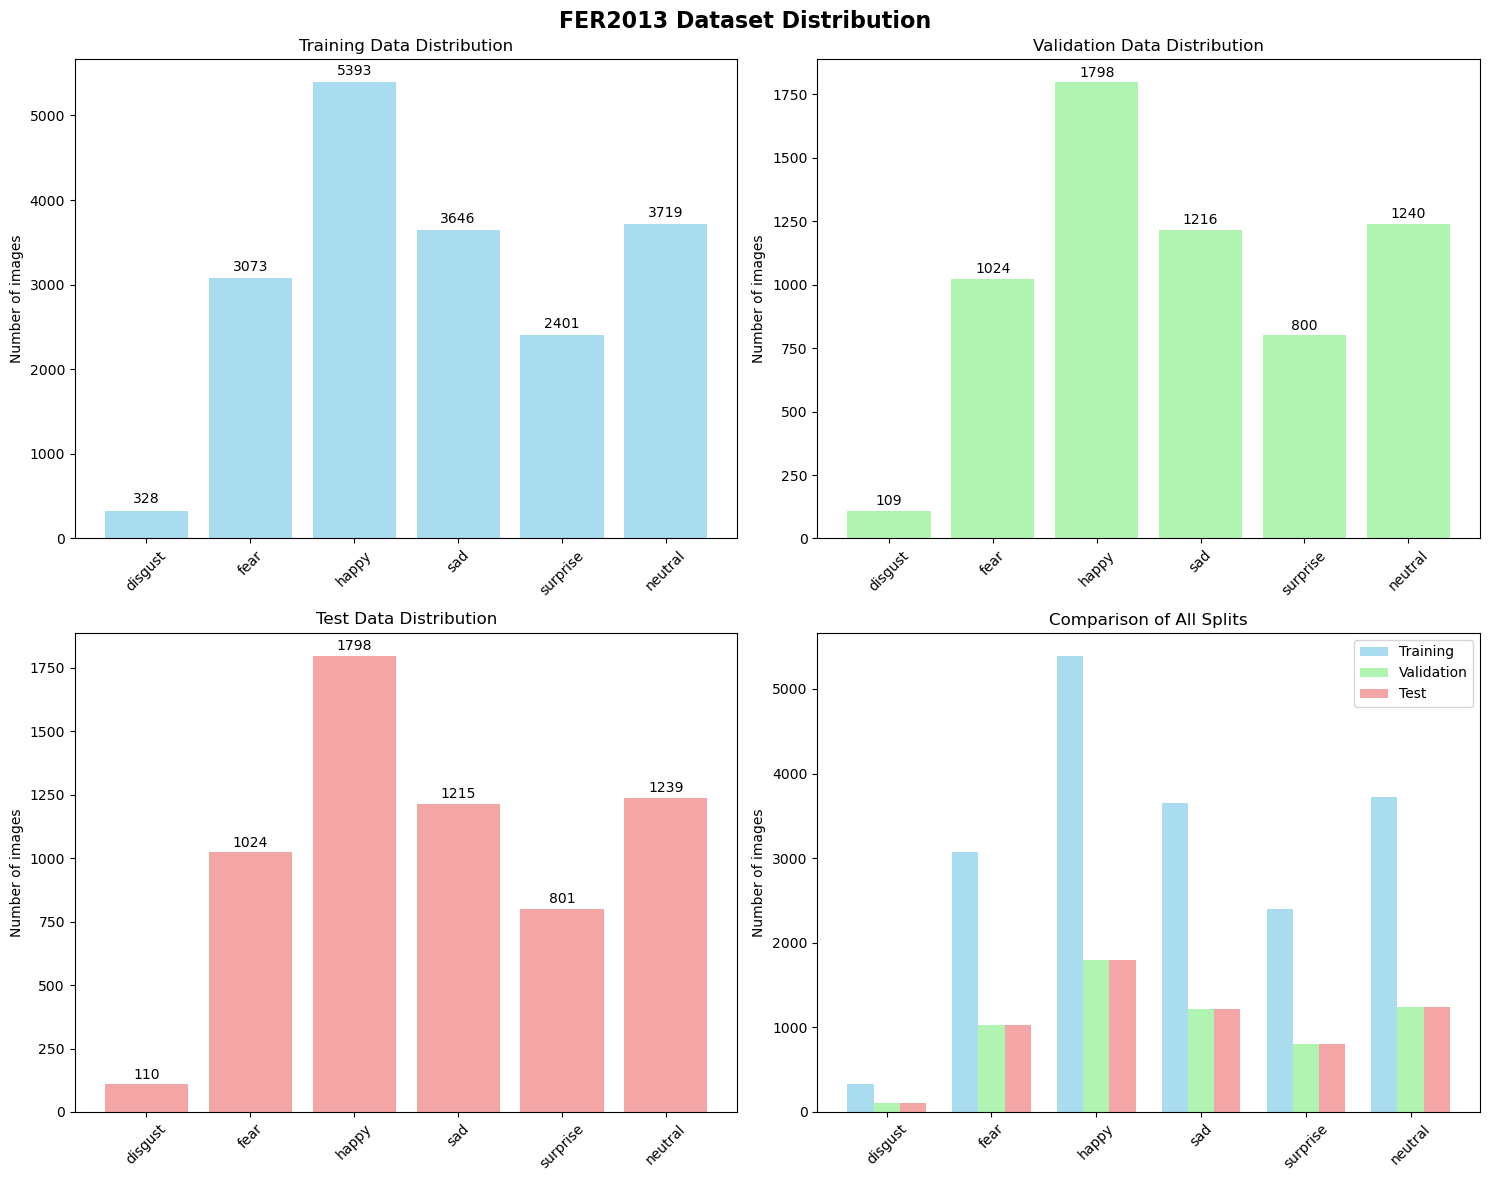


📊 Dataset Statistics:
Total images: 30934
Training: 18560 images
Validation: 6187 images
Test: 6187 images

⚖️ Imbalance Analysis:
------------------------------
disgust     :  547 images (  1.8%)
fear        : 5121 images ( 16.6%)
happy       : 8989 images ( 29.1%)
sad         : 6077 images ( 19.6%)
surprise    : 4002 images ( 12.9%)
neutral     : 6198 images ( 20.0%)

🔺 Most represented: happy (8989 images)
🔻 Least represented: disgust (547 images)
📈 Imbalance ratio: 16.4:1
CPU times: user 17 s, sys: 9.29 s, total: 26.3 s
Wall time: 2min 24s


In [10]:
%%time
# Run visualization
visualize_dataset_distribution(train_loader, val_loader, test_loader, class_names)

In [11]:
# Create a dictionary of class_names with display names
# We use English names with capitalization for visualization
class_names_display = {
    'disgust': 'Disgust',
    'fear': 'Fear',
    'happy': 'Happy',
    'sad': 'Sad',
    'surprise': 'Surprise',
    'neutral': 'Neutral'
}

# Use class_names_display in visualizations
display_names = [class_names_display[name] for name in class_names]

display_names


['Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

In [12]:
def visualize_sample_images(train_loader, class_names, num_samples=6):
    """Visualize sample images from each emotion class"""
    
    # Collect sample images from each class
    class_samples = {i: [] for i in range(len(class_names))}
    
    for images, labels in train_loader:
        for img, label in zip(images, labels):
            if len(class_samples[label.item()]) < num_samples:
                class_samples[label.item()].append(img)
        
        # Check if we have enough samples
        if all(len(samples) >= num_samples for samples in class_samples.values()):
            break
    
    # Create figure
    fig, axes = plt.subplots(len(class_names), num_samples, figsize=(15, 12))
    fig.suptitle('Sample Images from FER2013 Dataset', fontsize=16, fontweight='bold')
    
    for class_idx, emotion in enumerate(class_names):
        for sample_idx in range(num_samples):
            if sample_idx < len(class_samples[class_idx]):
                img = class_samples[class_idx][sample_idx]
                
                # Denormalize image for display
                img_denorm = img * 0.5 + 0.5  # Denormalize from [-1, 1] to [0, 1]
                img_denorm = torch.clamp(img_denorm, 0, 1)
                
                axes[class_idx, sample_idx].imshow(img_denorm.squeeze(), cmap='gray')
                axes[class_idx, sample_idx].set_title(f'{emotion}' if sample_idx == 0 else '')
                axes[class_idx, sample_idx].axis('off')
            else:
                axes[class_idx, sample_idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Analyze image quality
    print("\n🔍 Image Quality Analysis:")
    print("=" * 40)
    
    # Analyze a sample image
    sample_img = class_samples[0][0]  # First image from first class
    sample_img_denorm = sample_img * 0.5 + 0.5
    
    print(f"Image size: {sample_img.shape}")
    print(f"Pixel value range: [{sample_img.min():.3f}, {sample_img.max():.3f}]")
    print(f"Mean pixel value: {sample_img.mean():.3f}")
    print(f"Standard deviation: {sample_img.std():.3f}")
    
    # Check for potential issues
    if sample_img.min() < -1 or sample_img.max() > 1:
        print("⚠️ Warning: Pixel values outside expected range [-1, 1]")
    
    if sample_img.std() < 0.1:
        print("⚠️ Warning: Low contrast - image may be too dark or bright")



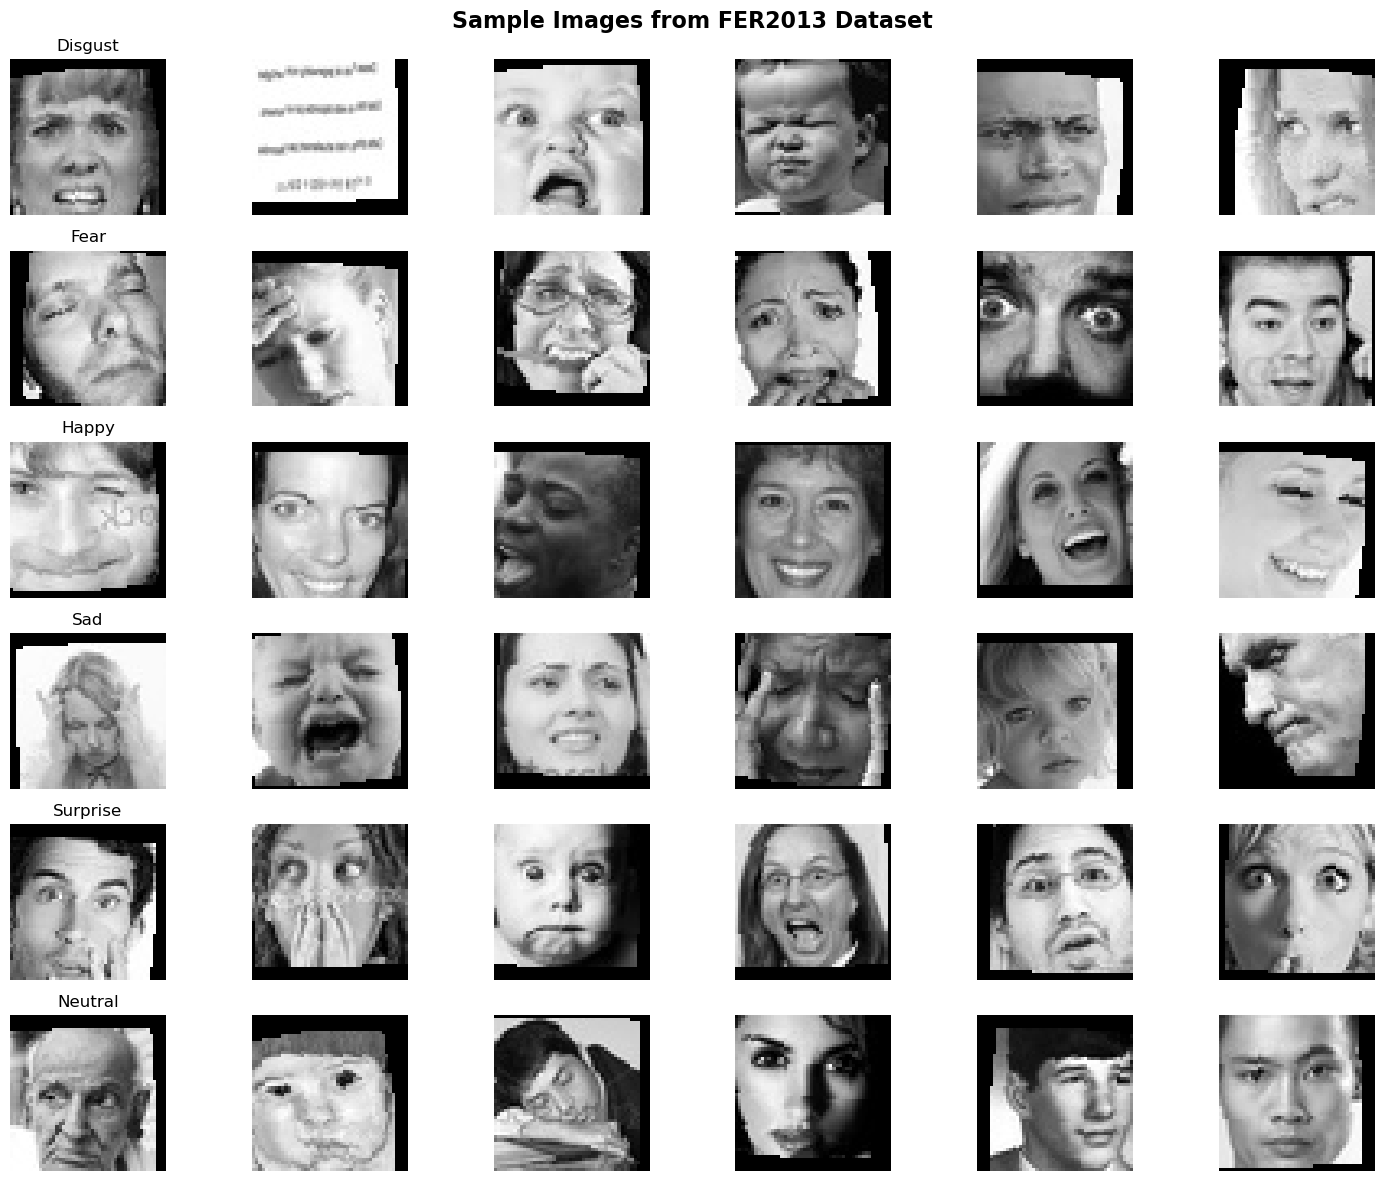


🔍 Image Quality Analysis:
Image size: torch.Size([1, 48, 48])
Pixel value range: [-1.000, 0.733]
Mean pixel value: -0.231
Standard deviation: 0.422
CPU times: user 265 ms, sys: 23.5 ms, total: 289 ms
Wall time: 357 ms


In [13]:
%%time
# Run visualization
visualize_sample_images(train_loader, display_names, num_samples=6)

## 4. Model Training

In [14]:
# =============================================================================
# TRAINING AND VALIDATION FUNCTIONS
# =============================================================================
#
# THE TRAINING LOOP (per batch):
#   1. optimizer.zero_grad()  - Clear gradients from previous batch
#   2. outputs = model(images) - Forward pass: compute predictions
#   3. loss = criterion(...)   - Compute loss (cross-entropy)
#   4. loss.backward()         - Backward pass: compute gradients
#   5. optimizer.step()        - Update weights using gradients
#
# TRAINING vs EVALUATION MODE:
#   model.train(): Enables dropout, BatchNorm uses batch statistics
#   model.eval():  Disables dropout, BatchNorm uses running statistics
#
# WHY torch.no_grad() IN VALIDATION:
#   - Saves memory (no gradient tensors stored)
#   - Speeds up computation
#   - We only need gradients during training
#
# =============================================================================

def train_epoch(model, dataloader, criterion, optimizer, device):
    """
    Train model for one epoch.
    
    Args:
        model: Neural network to train
        dataloader: Training data loader
        criterion: Loss function (CrossEntropyLoss)
        optimizer: Optimizer (Adam, SGD, etc.)
        device: CPU/GPU/MPS device
    
    Returns:
        epoch_loss: Average loss over all batches
        epoch_acc: Accuracy percentage
    """
    model.train()  # Enable training mode (dropout active, BatchNorm updates)
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in tqdm(dataloader, desc="Training"):
        images, labels = images.to(device), labels.to(device)
        
        # Step 1: Clear gradients
        optimizer.zero_grad()
        
        # Step 2: Forward pass
        outputs = model(images)
        
        # Step 3: Compute loss
        loss = criterion(outputs, labels)
        
        # Step 4: Backward pass (compute gradients)
        loss.backward()
        
        # Step 5: Update weights
        optimizer.step()
        
        # Track metrics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc

def validate_epoch(model, dataloader, criterion, device):
    """
    Validate model for one epoch (no gradient computation).
    
    This is used to monitor generalization during training.
    """
    model.eval()  # Disable dropout, use running BatchNorm statistics
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():  # No gradients needed - saves memory and time
        for images, labels in tqdm(dataloader, desc="Validation"):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc

def train_model(model, train_loader, val_loader, num_epochs=50, learning_rate=0.001):
    """
    Train the complete model.
    
    For reproducibility, set_seed() is called at the start.
    """
    # Reset seed at start of training for reproducibility
    set_seed(RANDOM_SEED)
    
    # Create model folder
    os.makedirs('./models', exist_ok=True)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)
    
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    best_val_acc = 0.0
    patience_counter = 0
    
    print("🏋️ Starting training...")
    print("=" * 50)
    
    start_time = time.time()
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 30)
        
        # Train
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        
        # Validate
        val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
        
        # Update learning rate
        scheduler.step(val_loss)
        
        # Store metrics
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
        print(f"Learning Rate: {optimizer.param_groups[0]['lr']:.6f}")
        
        # Early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            # Save best model
            torch.save(model.state_dict(), './models/best_emotion_model.pth')
            print(f"🏆 New best model saved! (Val Acc: {val_acc:.2f}%)")
        else:
            patience_counter += 1
            
        if patience_counter >= 10:
            print(f"\n⏹️ Early stopping at epoch {epoch+1}")
            break
    
    end_time = time.time()
    training_time = end_time - start_time
    
    print(f"\n✅ Training complete!")
    print(f"⏱️ Total training time: {training_time/60:.1f} minutes")
    print(f"🏆 Best validation accuracy: {best_val_acc:.2f}%")
    
    # Save training history
    history = {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accs': train_accs,
        'val_accs': val_accs,
        'best_val_acc': best_val_acc,
        'training_time': training_time,
        'epochs_trained': len(train_losses)
    }
    
    # Save history
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    with open(f'./models/training_history_{timestamp}.pkl', 'wb') as f:
        pickle.dump(history, f)
    
    return history

print("✅ Training functions defined!")

✅ Training functions defined!


#### Training the model takes more or less time depending on compute resources - CPU, MPS, GPU
Approx. 6 min locally with MPS (M4 Max) - approx. 10 min on Google Colab with T4 GPU (CUDA) - approx. 4 min locally with NVIDIA RTX A5000 Laptop GPU - and more than 30 min with CPU

In [15]:
%%time
# Start training
print("🎯 Starting model training...")
print("=" * 50)

# Training with reduced number of epochs for demo
history = train_model(model, train_loader, val_loader, num_epochs=30, learning_rate=0.001)

print("\n🎉 Training complete!")

🎯 Starting model training...
🏋️ Starting training...

Epoch 1/30
------------------------------


Validation: 100%|██████████| 194/194 [00:02<00:00, 91.00it/s] 


Train Loss: 1.6521, Train Acc: 27.14%
Val Loss: 1.6227, Val Acc: 29.35%
Learning Rate: 0.001000
🏆 New best model saved! (Val Acc: 29.35%)

Epoch 2/30
------------------------------


Validation: 100%|██████████| 194/194 [00:01<00:00, 106.43it/s]


Train Loss: 1.6277, Train Acc: 28.64%
Val Loss: 1.6052, Val Acc: 29.82%
Learning Rate: 0.001000
🏆 New best model saved! (Val Acc: 29.82%)

Epoch 3/30
------------------------------


...

Train Loss: 1.1007, Train Acc: 56.92%
Val Loss: 0.9815, Val Acc: 61.29%
Learning Rate: 0.001000

Epoch 29/30
------------------------------


Validation: 100%|██████████| 194/194 [00:01<00:00, 108.83it/s]


Train Loss: 1.0945, Train Acc: 57.62%
Val Loss: 0.9689, Val Acc: 61.76%
Learning Rate: 0.001000

Epoch 30/30
------------------------------


Validation: 100%|██████████| 194/194 [00:01<00:00, 106.61it/s]

Train Loss: 1.0861, Train Acc: 57.48%
Val Loss: 0.9542, Val Acc: 62.05%
Learning Rate: 0.001000

✅ Training complete!
⏱️ Total training time: 6.5 minutes
🏆 Best validation accuracy: 62.05%

🎉 Training complete!
CPU times: user 4min, sys: 59.3 s, total: 4min 59s
Wall time: 6min 28s


## 5. Evaluation and Visualization

In [16]:
def plot_training_history(history):
    """Visualize training history"""
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    epochs = range(1, len(history['train_losses']) + 1)
    
    # Loss plot
    ax1.plot(epochs, history['train_losses'], 'b-', label='Training Loss', linewidth=2)
    ax1.plot(epochs, history['val_losses'], 'r-', label='Validation Loss', linewidth=2)
    ax1.set_title('Model Loss Over Time', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Accuracy plot
    ax2.plot(epochs, history['train_accs'], 'b-', label='Training Accuracy', linewidth=2)
    ax2.plot(epochs, history['val_accs'], 'r-', label='Validation Accuracy', linewidth=2)
    ax2.set_title('Model Accuracy Over Time', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print("\n📊 Training Summary:")
    print("=" * 40)
    print(f"Epochs trained: {history['epochs_trained']}")
    print(f"Training time: {history['training_time']/60:.1f} minutes")
    print(f"Best validation accuracy: {history['best_val_acc']:.2f}%")
    print(f"Final training loss: {history['train_losses'][-1]:.4f}")
    print(f"Final validation loss: {history['val_losses'][-1]:.4f}")
    print(f"Final training accuracy: {history['train_accs'][-1]:.2f}%")
    print(f"Final validation accuracy: {history['val_accs'][-1]:.2f}%")


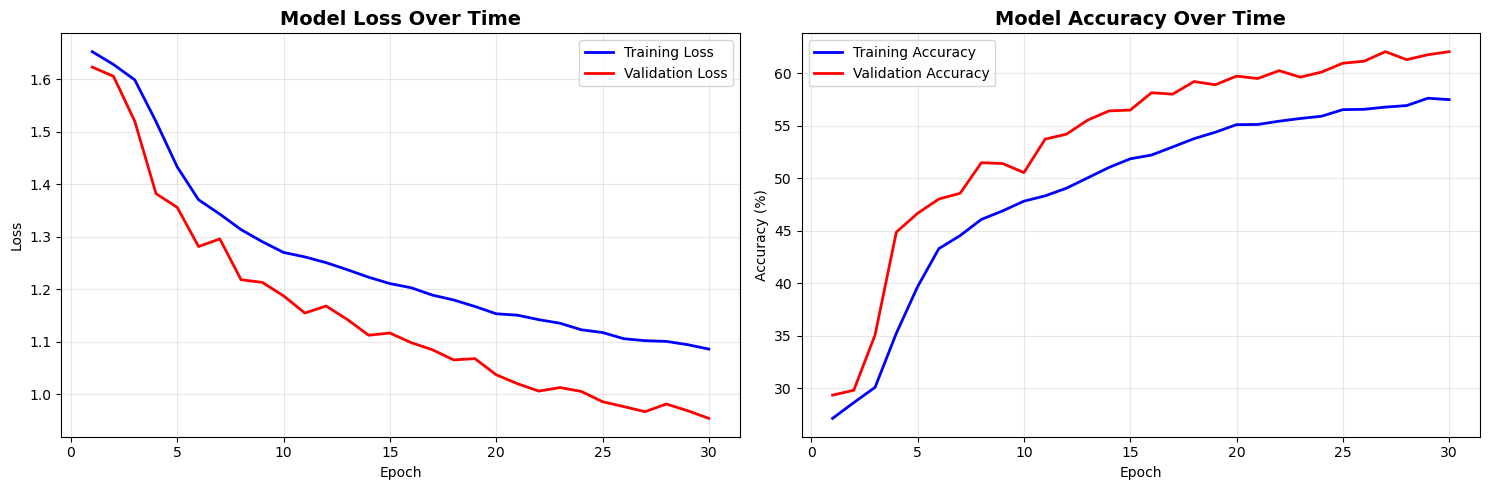


📊 Training Summary:
Epochs trained: 30
Training time: 6.5 minutes
Best validation accuracy: 62.05%
Final training loss: 1.0861
Final validation loss: 0.9542
Final training accuracy: 57.48%
Final validation accuracy: 62.05%


In [17]:
# Visualize training history
plot_training_history(history)

### An AI (Claude Opus 4.5) comments on these training results as follows:

**Prompt** _Describe and interpret these training curves and insert your answer into the notebook - after Training Summary:_

### 🤖 AI-Generated Analysis of the Training Curves

---

#### **1. Overview of Training Results**

| Metric | Start Value | End Value | Change |
|--------|-------------|-----------|--------|
| **Training Loss** | 1.65 | 1.08 | ↓ 34% |
| **Validation Loss** | 1.62 | 0.97 | ↓ 40% |
| **Training Accuracy** | ~28% | 57.7% | ↑ 106% |
| **Validation Accuracy** | ~30% | 62.1% | ↑ 107% |

---

#### **2. Interpretation of the Loss Curve (left)**

```
Loss
1.6 ┤ ●─●                     Training (blue)
    │    ╲                    Validation (red)
1.4 ┤      ╲ ─ ─
    │        ╲    ╲
1.2 ┤          ╲     ╲
    │            ──────╲
1.0 ┤                    ──── ● Validation
    │                    ────── ● Training
    └────────────────────────────────
    0     10      20      30  Epoch
```

**Observations:**
- ✅ **Continuous decline**: Both curves decrease steadily – the model is learning!
- ✅ **No divergence**: Curves follow each other – no overfitting
- 🔍 **Validation loss < Training loss**: Unusual pattern (explained below)

---

#### **3. Interpretation of the Accuracy Curve (right)**

```
Accuracy (%)
   62 ┤                        ● Validation (red)
      │                    ─────
   55 ┤               ─────────── ● Training (blue)
      │          ─────
   45 ┤     ─────
      │ ─────
   30 ┤●
      └────────────────────────────────
      0     10      20      30  Epoch
```

**Observations:**
- ✅ **Fast learning** (epoch 0-10): Accuracy increases from ~28% to ~50%
- ✅ **Gradual improvement** (epoch 10-30): Stabilizes toward ~60%
- 🔍 **Validation accuracy > Training accuracy**: Unusual – explained below

---

#### **4. Why is Validation Better Than Training? 🤔**

This is **not overfitting** – it's the opposite! The explanation lies in **regularization**:

| Technique | During Training | During Validation |
|-----------|-----------------|-------------------|
| **Dropout** | Active (turns off neurons) | Inactive (all neurons used) |
| **Data Augmentation** | Active (rotation, flip, etc.) | Inactive (original images) |
| **BatchNorm** | Batch statistics | Average statistics |

```
┌────────────────────────────────────────────────────────────────────┐
│  TRAINING:                          VALIDATION:                    │
│                                                                    │
│  Image → [Augmented] → CNN → [Dropout 50%] → Prediction            │
│  Image → [Original]  → CNN → [Full model]  → Prediction            │
│                                                                    │
│  Harder task!                       Easier task!                   │
└────────────────────────────────────────────────────────────────────┘
```

> 💡 **Conclusion**: The model is **robust** and generalizes well!

---

#### **5. Assessment of 62% Accuracy**

| Context | Assessment |
|---------|------------|
| **FER2013 benchmark** | Below state-of-the-art (~75%) |
| **6-class problem** | Random would give ~17% |
| **Medical screening** | Acceptable as a support tool |
| **Diagnostics** | ❌ Not sufficient alone |

**Class imbalance affects:**
- 😊 Happy: Many images → Good performance
- 🤢 Disgust: Few images → Weaker performance

---

#### **6. What Can Improve the Model?**

| Action | Expected Effect |
|--------|-----------------|
| **Class weighting** | Better performance on underrepresented classes |
| **More data augmentation** | Increased robustness |
| **Transfer learning** (ResNet, EfficientNet) | +5-10% accuracy |
| **Vision Transformer** | +10-15% accuracy |
| **Ensemble** | +2-5% accuracy |

---

#### **7. Clinical Implications**

```
┌──────────────────────────────────────────────────────────────────┐
│                    CLINICAL USE                                  │
├──────────────────────────────────────────────────────────────────┤
│  ✅ SUITABLE FOR:                                                │
│     • Screening patients for further evaluation                  │
│     • Monitoring mood changes over time                          │
│     • Objective support for clinical assessment                  │
│                                                                  │
│  ❌ NOT SUITABLE FOR:                                            │
│     • Final diagnostics                                          │
│     • Treatment decisions alone                                  │
│     • Legal or insurance documentation                           │
└──────────────────────────────────────────────────────────────────┘
```

> 🏥 **Important**: An AI with 62% accuracy can be a useful **screening tool**, but must always be combined with clinical expertise!

# 6. Evaluate Model on Test Set

In Colab, models are saved in the current working directory (/content), not in the repository folder

In [18]:
if IN_COLAB:
    # Check where the model was saved
    import os
    from pathlib import Path

    print("🔍 Searching for model files...")
    print(f"Current folder: {os.getcwd()}")

    # Search in all of /content
    model_files = list(Path('/content').rglob('*.pth'))
    print(f"\n📁 Found {len(model_files)} .pth files:")
    for file in model_files:
        print(f"  - {file}")
        print(f"    Size: {file.stat().st_size / 1024 / 1024:.1f} MB")

    # Also check models folder
    if os.path.exists('./models'):
        print(f"\n📂 Contents of ./models:")
        for item in os.listdir('./models'):
            print(f"  - {item}")
    else:
        print("\n❌ ./models folder does not exist")

In [19]:
if IN_COLAB:
    # Create models folder if it doesn't exist
    os.makedirs('./models', exist_ok=True)

    # If model was saved in /content, move it
    if os.path.exists('/content/models/best_emotion_model.pth'):
        import shutil
        shutil.copy('/content/models/best_emotion_model.pth', './models/best_emotion_model.pth')
        print("✅ Model moved to ./models/")
    elif os.path.exists('/content/best_emotion_model.pth'):
        import shutil
        shutil.copy('/content/best_emotion_model.pth', './models/best_emotion_model.pth')
        print("✅ Model moved to ./models/")
    else:
        print("❌ Model was not found")

In [20]:
# After the model has been trained and saved
if IN_COLAB:
    # Create tmp folder for GitHub
    os.makedirs('./tmp', exist_ok=True)
    
    # Copy model to tmp folder
    import shutil
    if os.path.exists('./models/best_emotion_model.pth'):
        shutil.copy('./models/best_emotion_model.pth', './tmp/best_emotion_model.pth')
        print("✅ Model copied to ./tmp/ for GitHub upload")
        
        # Instructions for student
        print("\n📋 Instructions for uploading to GitHub:")
        print("1. Go to GitHub repository: https://github.com/arvidl/BMED365-2026")
        print("2. Navigate to: Lab2-DL/tmp/")
        print("3. Click 'Upload files'")
        print("4. Drag and drop best_emotion_model.pth file")
        print("5. Commit with message: 'Add trained emotion model'")
        print("6. Click 'Commit changes'")
        
        # Show file size
        file_size = os.path.getsize('./tmp/best_emotion_model.pth') / 1024 / 1024
        print(f"\n📊 Model size: {file_size:.1f} MB")
        
    else:
        print("❌ Model not found in ./models/")

In [21]:
if IN_COLAB:
    print("🔍 Checking Google Drive...")
    # Create tmp folder
    os.makedirs('./tmp', exist_ok=True)
    
    if os.path.exists('./models/best_emotion_model.pth'):
        shutil.copy('./models/best_emotion_model.pth', './tmp/best_emotion_model.pth')
        
        file_size = os.path.getsize('./tmp/best_emotion_model.pth') / 1024 / 1024
        print(f"📊 Model size: {file_size:.1f} MB")
        
        if file_size > 100:
            print("❌ Model is too large (>100 MB)")
        else:
            try:
                # Use Google Drive
                from google.colab import drive
                drive.mount('/content/drive')
                
                # Copy to Google Drive
                shutil.copy('./tmp/best_emotion_model.pth', 
                           '/content/drive/MyDrive/best_emotion_model.pth')
                
                print("✅ Model saved to Google Drive!")
                print("📁 File: /content/drive/MyDrive/best_emotion_model.pth")
                
            except Exception as e:
                print(f"❌ Google Drive upload failed: {e}")
                print("💡 Manual upload required")

In [22]:
# Evaluate model on test set
def evaluate_model_comprehensive(model, test_loader, class_names, device):
    """Comprehensive evaluation of the model on test set"""
    
    model.eval()
    all_predictions = []
    all_labels = []
    all_probabilities = []
    
    print("🔍 Evaluating model on test set...")
    
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Evaluation"):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            probabilities = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())
    
    # Convert to numpy arrays
    all_predictions = np.array(all_predictions)
    all_labels = np.array(all_labels)
    all_probabilities = np.array(all_probabilities)
    
    # Calculate accuracy
    accuracy = (all_predictions == all_labels).mean() * 100
    
    print(f"\n🎯 Test Results:")
    print(f"Test Accuracy: {accuracy:.2f}%")
    
    return all_predictions, all_labels, all_probabilities, accuracy


In [23]:
# Load best model if available
if os.path.exists('./models/best_emotion_model.pth'):
    model.load_state_dict(torch.load('./models/best_emotion_model.pth', map_location=device))
    print("✅ Best model loaded!")
else:
    print("⚠️ Best model not found - using current model")

✅ Best model loaded!


In [24]:
# Evaluate model
predictions, true_labels, probabilities, test_accuracy = evaluate_model_comprehensive(model, test_loader, class_names, device)


🔍 Evaluating model on test set...


Evaluation: 100%|██████████| 194/194 [00:01<00:00, 105.12it/s]


🎯 Test Results:
Test Accuracy: 62.66%


In [25]:
# 1. Confusion Matrix
def plot_confusion_matrix(y_true, y_pred, class_names):
    """Plot confusion matrix with detailed analysis"""
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Normalize confusion matrix
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Absolute confusion matrix
    im1 = ax1.imshow(cm, interpolation='nearest', cmap='Blues')
    ax1.set_title('Confusion Matrix (Absolute)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Predicted class')
    ax1.set_ylabel('True class')
    
    # Add numbers in cells
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax1.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black",
                    fontsize=12, fontweight='bold')
    
    ax1.set_xticks(range(len(class_names)))
    ax1.set_yticks(range(len(class_names)))
    ax1.set_xticklabels(class_names, rotation=45)
    ax1.set_yticklabels(class_names)
    
    # Normalized confusion matrix
    im2 = ax2.imshow(cm_normalized, interpolation='nearest', cmap='Blues')
    ax2.set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Predicted class')
    ax2.set_ylabel('True class')
    
    # Add percentages in cells
    for i in range(cm_normalized.shape[0]):
        for j in range(cm_normalized.shape[1]):
            ax2.text(j, i, format(cm_normalized[i, j], '.2f'),
                    ha="center", va="center",
                    color="white" if cm_normalized[i, j] > 0.5 else "black",
                    fontsize=12, fontweight='bold')
    
    ax2.set_xticks(range(len(class_names)))
    ax2.set_yticks(range(len(class_names)))
    ax2.set_xticklabels(class_names, rotation=45)
    ax2.set_yticklabels(class_names)
    
    plt.tight_layout()
    plt.show()
    
    # Detailed analysis of confusion matrix
    print("\n📊 Confusion Matrix Analysis:")
    print("=" * 50)
    
    # Per-class accuracy
    print("\n✅ Per-class accuracy:")
    for i, class_name in enumerate(class_names):
        class_accuracy = cm[i, i] / cm[i, :].sum() * 100
        print(f"  {class_name:12}: {class_accuracy:6.2f}% ({cm[i, i]:4d}/{cm[i, :].sum():4d})")
    
    # Most common misclassifications
    print("\n❌ Most common misclassifications:")
    errors = []
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            if i != j and cm[i, j] > 0:
                errors.append((cm[i, j], class_names[i], class_names[j]))
    
    errors.sort(reverse=True)
    for count, true_class, pred_class in errors[:5]:
        print(f"  {true_class} → {pred_class}: {count:3d} times")
    
    return cm, cm_normalized

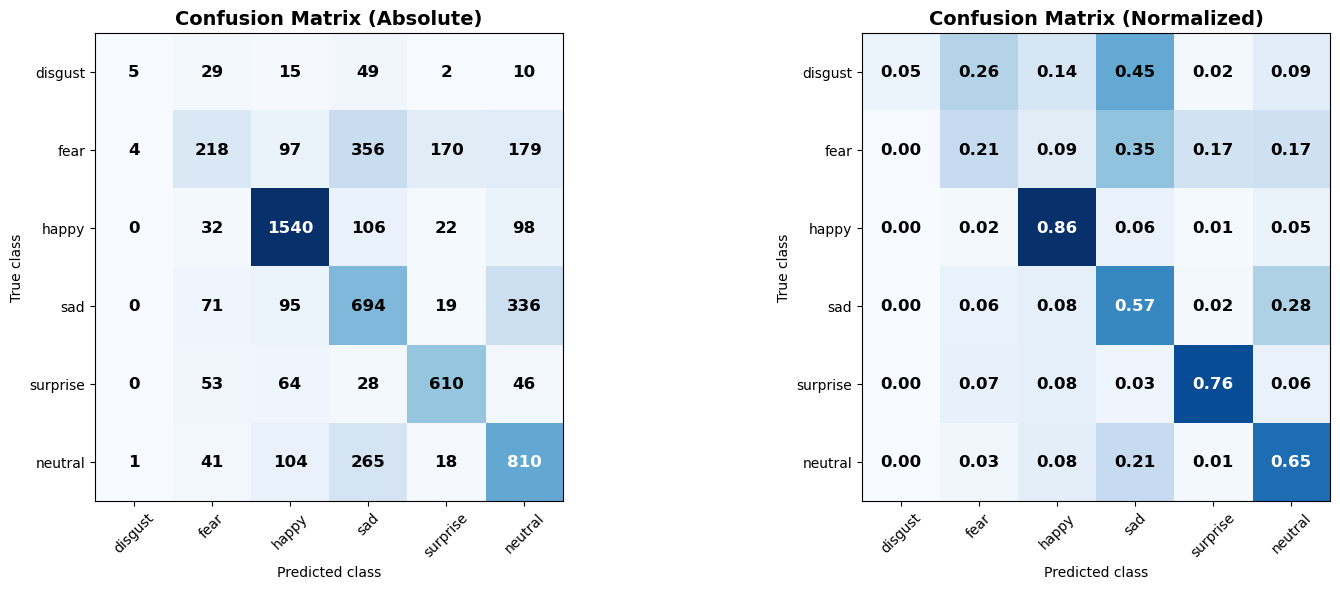


📊 Confusion Matrix Analysis:

✅ Per-class accuracy:
  disgust     :   4.55% (   5/ 110)
  fear        :  21.29% ( 218/1024)
  happy       :  85.65% (1540/1798)
  sad         :  57.12% ( 694/1215)
  surprise    :  76.15% ( 610/ 801)
  neutral     :  65.38% ( 810/1239)

❌ Most common misclassifications:
  fear → sad: 356 times
  sad → neutral: 336 times
  neutral → sad: 265 times
  fear → neutral: 179 times
  fear → surprise: 170 times


In [26]:
# Plot confusion matrix
cm, cm_normalized = plot_confusion_matrix(true_labels, predictions, class_names)

In [27]:
# 2. Detailed Prediction Metrics
def calculate_detailed_metrics(y_true, y_pred, y_prob, class_names):
    """Calculate detailed prediction metrics"""
    
    from sklearn.metrics import precision_recall_fscore_support, classification_report
    import pandas as pd
    
    # Calculate metrics
    precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, average=None)
    
    # Create DataFrame for better display
    metrics_df = pd.DataFrame({
        'Class': class_names,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Support': support
    })
    
    # Add macro and weighted averages
    macro_precision = np.mean(precision)
    macro_recall = np.mean(recall)
    macro_f1 = np.mean(f1)
    
    weighted_precision = np.average(precision, weights=support)
    weighted_recall = np.average(recall, weights=support)
    weighted_f1 = np.average(f1, weights=support)
    
    print("\n📊 Detailed Prediction Metrics:")
    print("=" * 60)
    
    # Show per-class metrics
    print("\nPer-class metrics:")
    print(metrics_df.round(3).to_string(index=False))
    
    # Show summary
    print(f"\n📈 Summary:")
    print(f"  Macro average:")
    print(f"    Precision: {macro_precision:.3f}")
    print(f"    Recall:    {macro_recall:.3f}")
    print(f"    F1-Score:  {macro_f1:.3f}")
    
    print(f"\n  Weighted average:")
    print(f"    Precision: {weighted_precision:.3f}")
    print(f"    Recall:    {weighted_recall:.3f}")
    print(f"    F1-Score:  {weighted_f1:.3f}")
    
    # Show classification report
    print(f"\n📋 Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=3))
    
    return metrics_df, macro_precision, macro_recall, macro_f1, weighted_precision, weighted_recall, weighted_f1


In [28]:
# Calculate detailed metrics
metrics_df, macro_precision, macro_recall, macro_f1, weighted_precision, weighted_recall, weighted_f1 = calculate_detailed_metrics(true_labels, predictions, probabilities, class_names)



📊 Detailed Prediction Metrics:

Per-class metrics:
   Class  Precision  Recall  F1-Score  Support
 disgust      0.500   0.045     0.083      110
    fear      0.491   0.213     0.297     1024
   happy      0.804   0.857     0.830     1798
     sad      0.463   0.571     0.512     1215
surprise      0.725   0.762     0.743      801
 neutral      0.548   0.654     0.596     1239

📈 Summary:
  Macro average:
    Precision: 0.589
    Recall:    0.517
    F1-Score:  0.510

  Weighted average:
    Precision: 0.618
    Recall:    0.627
    F1-Score:  0.608

📋 Classification Report:
              precision    recall  f1-score   support

     disgust      0.500     0.045     0.083       110
        fear      0.491     0.213     0.297      1024
       happy      0.804     0.857     0.830      1798
         sad      0.463     0.571     0.512      1215
    surprise      0.725     0.762     0.743       801
     neutral      0.548     0.654     0.596      1239

    accuracy                         

In [29]:
# 3. Confidence Analysis
def analyze_confidence(predictions, true_labels, probabilities, class_names):
    """Analyze model confidence in predictions"""
    
    # Calculate confidence for each prediction
    confidences = np.max(probabilities, axis=1)
    
    # Split into correct and incorrect predictions
    correct_mask = predictions == true_labels
    correct_confidences = confidences[correct_mask]
    incorrect_confidences = confidences[~correct_mask]
    
    # Create figure
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Confidence Analysis of Model Predictions', fontsize=16, fontweight='bold')
    
    # 1. Confidence distribution
    ax1.hist(correct_confidences, bins=20, alpha=0.7, label='Correct', color='green')
    ax1.hist(incorrect_confidences, bins=20, alpha=0.7, label='Incorrect', color='red')
    ax1.set_xlabel('Confidence')
    ax1.set_ylabel('Number of predictions')
    ax1.set_title('Confidence Distribution')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Confidence vs accuracy
    confidence_bins = np.linspace(0, 1, 11)
    bin_centers = (confidence_bins[:-1] + confidence_bins[1:]) / 2
    accuracies = []
    
    for i in range(len(confidence_bins) - 1):
        mask = (confidences >= confidence_bins[i]) & (confidences < confidence_bins[i + 1])
        if np.sum(mask) > 0:
            acc = np.mean(correct_mask[mask])
            accuracies.append(acc)
        else:
            accuracies.append(0)
    
    ax2.plot(bin_centers, accuracies, 'o-', linewidth=2, markersize=6)
    ax2.set_xlabel('Confidence')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Confidence vs Accuracy')
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(0, 1)
    
    # 3. Per-class confidence
    class_confidences = []
    for i, class_name in enumerate(class_names):
        class_mask = true_labels == i
        if np.sum(class_mask) > 0:
            class_conf = np.mean(confidences[class_mask])
            class_confidences.append(class_conf)
        else:
            class_confidences.append(0)
    
    bars = ax3.bar(class_names, class_confidences, color='skyblue', alpha=0.7)
    ax3.set_xlabel('Emotion Class')
    ax3.set_ylabel('Average Confidence')
    ax3.set_title('Average Confidence per Class')
    ax3.tick_params(axis='x', rotation=45)
    
    # Add numbers on bars
    for bar, conf in zip(bars, class_confidences):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{conf:.3f}', ha='center', va='bottom')
    
    # 4. Confidence vs error type
    error_types = []
    error_confidences = []
    
    for i in range(len(predictions)):
        if predictions[i] != true_labels[i]:
            true_class = class_names[true_labels[i]]
            pred_class = class_names[predictions[i]]
            error_type = f"{true_class}→{pred_class}"
            error_types.append(error_type)
            error_confidences.append(confidences[i])
    
    # Select most common error types
    from collections import Counter
    error_counts = Counter(error_types)
    common_errors = [error for error, count in error_counts.most_common(5)]
    
    common_error_confidences = []
    for error_type in common_errors:
        mask = np.array(error_types) == error_type
        common_error_confidences.append([error_confidences[i] for i in range(len(error_confidences)) if mask[i]])
    
    ax4.boxplot(common_error_confidences, labels=common_errors)
    ax4.set_xlabel('Error Type')
    ax4.set_ylabel('Confidence')
    ax4.set_title('Confidence for Most Common Error Types')
    ax4.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Print confidence statistics
    print("\n📊 Confidence Statistics:")
    print("=" * 40)
    print(f"Average confidence (all): {np.mean(confidences):.3f}")
    print(f"Average confidence (correct): {np.mean(correct_confidences):.3f}")
    print(f"Average confidence (incorrect): {np.mean(incorrect_confidences):.3f}")
    print(f"Standard deviation confidence: {np.std(confidences):.3f}")
    
    # High confidence errors
    high_conf_errors = np.sum((confidences > 0.8) & (~correct_mask))
    print(f"\nHigh confidence errors (>0.8): {high_conf_errors} ({high_conf_errors/len(predictions)*100:.1f}%)")
    
    # Low confidence correct
    low_conf_correct = np.sum((confidences < 0.5) & (correct_mask))
    print(f"Low confidence correct (<0.5): {low_conf_correct} ({low_conf_correct/len(predictions)*100:.1f}%)")

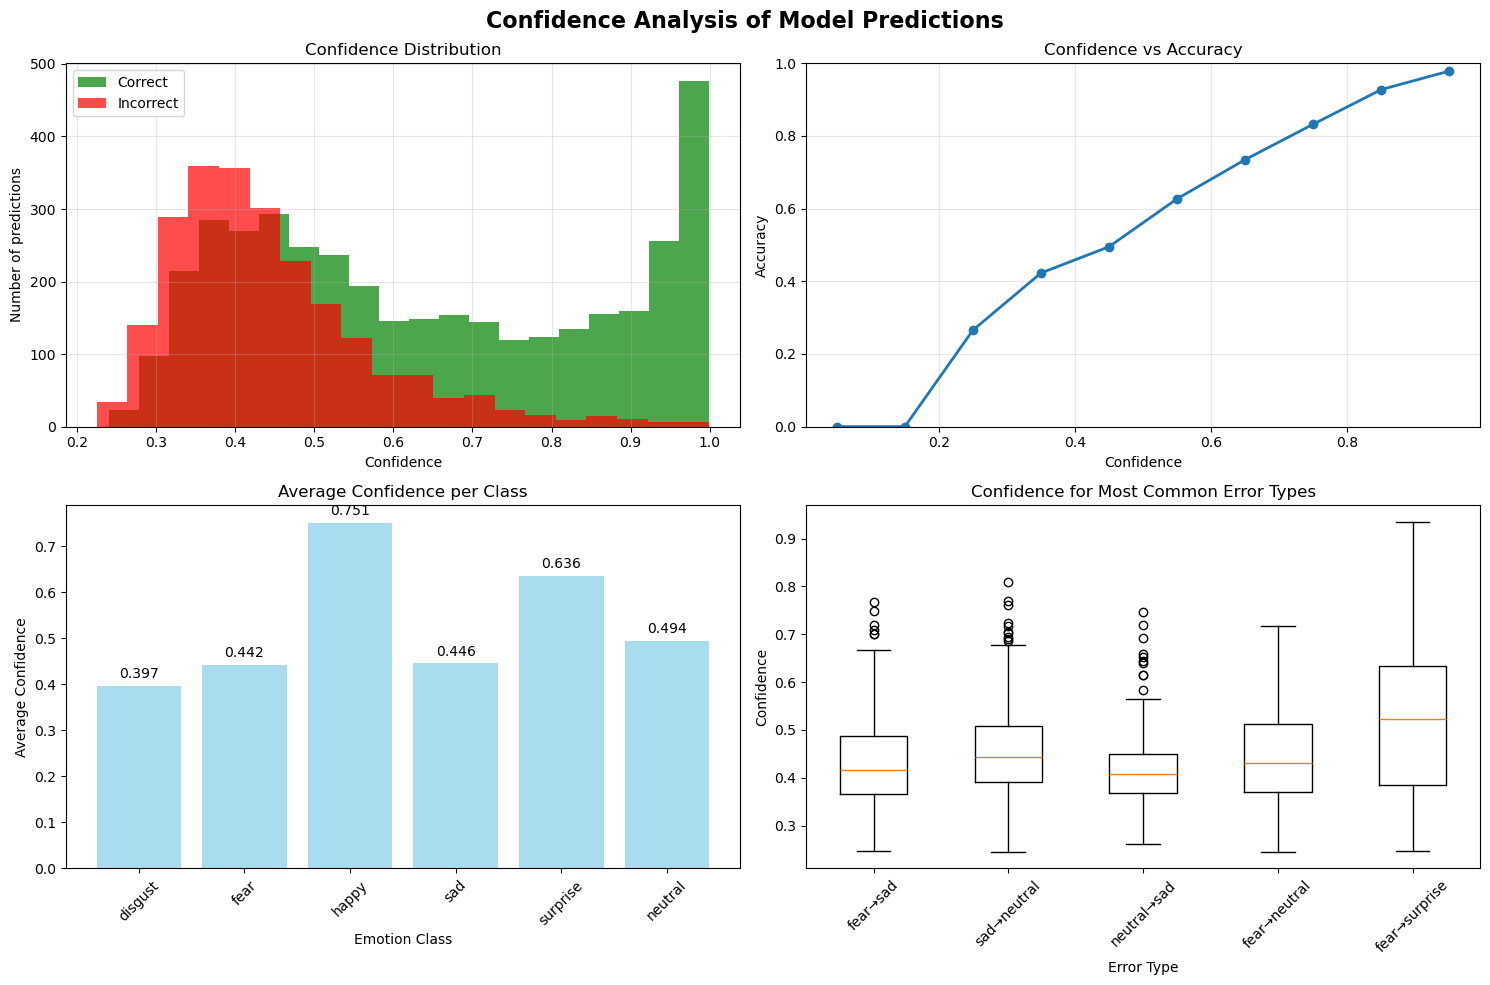


📊 Confidence Statistics:
Average confidence (all): 0.567
Average confidence (correct): 0.642
Average confidence (incorrect): 0.443
Standard deviation confidence: 0.218

High confidence errors (>0.8): 47 (0.8%)
Low confidence correct (<0.5): 1386 (22.4%)


In [30]:
# Run confidence analysis
analyze_confidence(predictions, true_labels, probabilities, class_names)

In [31]:
# 4. Overall Evaluation Summary
print("\n📋 Overall Evaluation Summary:")
print("=" * 50)
print(f"Test accuracy: {test_accuracy:.2f}%")
print(f"Macro F1-score: {macro_f1:.3f}")
print(f"Weighted F1-score: {weighted_f1:.3f}")
print(f"Number of test images: {len(predictions)}")
print(f"Number of classes: {len(class_names)}")


📋 Overall Evaluation Summary:
Test accuracy: 62.66%
Macro F1-score: 0.510
Weighted F1-score: 0.608
Number of test images: 6187
Number of classes: 6


In [32]:
# Compare with training results
if 'history' in locals():
    final_train_acc = history['train_accs'][-1]
    final_val_acc = history['val_accs'][-1]
    print(f"\n🔄 Comparison with training:")
    print(f"  Final training accuracy: {final_train_acc:.2f}%")
    print(f"  Final validation accuracy: {final_val_acc:.2f}%")
    print(f"  Test accuracy: {test_accuracy:.2f}%")
    
    # Check for overfitting
    if test_accuracy < final_val_acc - 2:
        print("  ⚠️ Possible overfitting (test < val - 2%)")
    elif test_accuracy > final_val_acc + 2:
        print("  ✅ Good generalization (test > val + 2%)")
    else:
        print("  ✅ Stable generalization")


🔄 Comparison with training:
  Final training accuracy: 57.48%
  Final validation accuracy: 62.05%
  Test accuracy: 62.66%
  ✅ Stable generalization


## 7. But: What Does the EU AI Act Say About This Application?

[ Good question! ]


### 🏛️ **EU AI Act - Analysis of Emotion Recognition**

#### **1. Risk Classification**

**Emotion recognition falls under "High-Risk AI Systems"** because:

##### **Annex III, point 1(a):**
> *"AI systems intended to be used for biometric identification and categorisation of natural persons"*

**Emotion recognition** = **Biometric categorization** of persons based on facial expressions

##### **Annex III, point 1(c):**
> *"AI systems intended to be used for emotion recognition"*

**Directly relevant** - emotion recognition is explicitly mentioned as high-risk

#### **2. Medical Application - Additional Requirements**

**If used in medical context**, the following also applies:

##### **Annex III, point 2(a):**
> *"AI systems intended to be used as safety components of medical devices"*

**Depression screening, pain assessment** = Medical application


#### **3. Specific Requirements from EU AI Act**

##### **A. Transparency and Documentation**

In [33]:
# Example of documentation requirements
AI_SYSTEM_DOCUMENTATION = {
    "system_description": "CNN for emotion recognition in medical screening",
    "intended_purpose": "Screening for depression/pain, NOT diagnostics",
    "accuracy_metrics": {
        "overall_accuracy": "62%",
        "per_class_accuracy": "Varies significantly",
        "bias_assessment": "Required"
    },
    "limitations": [
        "Missing anger class",
        "Dataset imbalance",
        "Not validated for all demographic groups"
    ]
}

##### **B. Human Oversight**
- **Mandatory**: Clinical expert must evaluate all AI recommendations
- **Prohibited**: Automatic diagnostics without human evaluation
- **Requirement**: Clear labeling of AI-generated results

##### **C. Data Quality and Bias**

In [34]:
# Bias analysis requirements
BIAS_REQUIREMENTS = {
    "demographic_parity": "Test across age, gender, ethnicity",
    "accuracy_parity": "Ensure similar performance across groups", 
    "data_provenance": "Document training data sources",
    "bias_mitigation": "Implement fairness constraints"
}

#### **4. Conformity Requirements**

##### **A. Technical Documents**
- **System architecture**: ✅ Our CNN architecture is documented
- **Data quality**: ⚠️ Imbalance in FER2013 must be addressed
- **Bias analysis**: ❌ Systematic bias testing is missing

##### **B. Risk Assessment**

In [35]:
RISK_ASSESSMENT = {
    "harm_potential": "Medium-High",
    "scenarios": [
        "Feil klassifisering av depresjon → Delayed treatment",
        "Bias mot minoriteter → Unequal care",
        "Over-reliance on AI → Reduced clinical judgment"
    ],
    "mitigation_measures": [
        "Human-in-the-loop validation",
        "Clear accuracy limitations",
        "Regular bias monitoring"
    ]
}

#### **5. Practical Implications**

##### **A. Before Commercialization**
1. **CE marking** required
2. **Notified Body** assessment
3. **Conformity declaration**
4. **EU database** registration

##### **B. During Use**
1. **Logging** of all decisions
2. **Human oversight** of each recommendation
3. **Bias monitoring** continuous
4. **User information** about limitations

#### **6. Comparison with Our Model**

| **EU AI Act Requirement** | **Our Model Status** | **Action** |
|---------------------------|---------------------|------------|
| **Documentation** | ✅ Partial | Complete system documentation |
| **Bias analysis** | ❌ Missing | Implement fairness metrics |
| **Human oversight** | ❌ Not implemented | Add human-in-the-loop |
| **Transparency** | ⚠️ Partial | Improve explainability (CAM/Grad-CAM) |
| **Data quality** | ⚠️ Imbalance | Address class imbalance |

#### **7. Recommendations for Compliance**

##### **Short-term (Before implementation):**

In [36]:
COMPLIANCE_CHECKLIST = [
    "✅ Implement bias testing",
    "✅ Add human oversight",
    "✅ Document limitations clearly",
    "✅ Implement logging system",
    "✅ Create user guide with warnings"
]

##### **Long-term (For commercialization):**

In [37]:
COMMERCIALIZATION_REQUIREMENTS = [
    "🔲 CE marking process",
    "🔲 Notified Body assessment", 
    "🔲 Conformity declaration",
    "🔲 EU database registration",
    "🔲 Legal assessment"
]

#### **8. Conclusion**

**Our emotion recognition model:**
- **Falls under EU AI Act** as a high-risk system
- **Requires extensive compliance** before medical use
- **62% accuracy** is too low for standalone diagnostics
- **Should be used as a screening tool** with human oversight

**Next steps**: Implement bias analysis, human oversight, and improve documentation to achieve compliance with the EU AI Act.

---

### ✅ Check Your Understanding

**Q1:** Why does the confusion matrix show that "disgust" and "fear" are often confused with each other?

<details>
<summary>Click for answer</summary>

**Several factors contribute:**

1. **Visual similarity:** Both involve furrowed brows, wrinkled nose
2. **Class imbalance:** "Disgust" has fewer training samples
3. **Subtle differences:** The distinguishing features are subtle even for humans
4. **Dataset quality:** FER2013 was crowd-labeled, introducing noise

**This is why per-class metrics matter:** Overall accuracy can hide poor performance on specific classes.
</details>

**Q2:** According to the EU AI Act, why is emotion recognition classified as "high-risk" in certain contexts?

<details>
<summary>Click for answer</summary>

**Emotion AI is high-risk in contexts like:**

| Context | Risk |
|---------|------|
| **Workplace** | Unfair hiring/firing decisions based on expressions |
| **Education** | Penalizing students for perceived lack of engagement |
| **Law enforcement** | False conclusions about intent or guilt |
| **Healthcare** | Misdiagnosis affecting treatment |

**Key concerns:**
- Expressions vary by culture, disability, and individual
- Risk of discrimination against certain groups
- Privacy implications of continuous monitoring
- Potential for manipulation and coercion
</details>

**Q3:** What does a high training accuracy but low validation accuracy indicate?

<details>
<summary>Click for answer</summary>

**This pattern indicates OVERFITTING:**

```
Training accuracy:   95%  ← Model memorized training data
Validation accuracy: 60%  ← But fails on new data
```

**The model has:**
- Learned noise and specific examples, not general patterns
- Too much capacity relative to dataset size
- Insufficient regularization

**Solutions:**
- Add more data or augmentation
- Increase dropout rate
- Use early stopping
- Reduce model complexity
- Add L2 regularization (weight decay)
</details>

**Q4:** Why is "human-in-the-loop" especially important for emotion AI in clinical settings?

<details>
<summary>Click for answer</summary>

**Clinical emotion AI should assist, not replace, human judgment because:**

| Reason | Explanation |
|--------|-------------|
| **Context matters** | A "sad" expression might be pain, fatigue, or concentration |
| **Cultural variation** | Expression norms differ across cultures |
| **Individual differences** | Baseline expressions vary (e.g., in Parkinson's disease) |
| **Stakes are high** | Misclassification could affect diagnosis and treatment |
| **Accountability** | Clinicians must be able to explain and justify decisions |

The AI should provide information; the clinician integrates it with full patient context.
</details>

> 🏛️ **Regulatory Note:** The EU AI Act requires transparency, human oversight, and bias testing for high-risk AI systems. Emotion recognition in sensitive contexts (employment, education, law enforcement) faces strict requirements or outright bans.

---

## 8. Summary of Part 2

**Part 2** of the notebook has completed:

✅ **Environment setup** - Works on Colab, Codespaces and locally<br>
✅ **Device detection** - Automatic GPU/MPS/CPU selection<br>
✅ **Visual inspection of data** - FER2013 dataset with 6 emotion classes<br>
✅ **Model training** - Of the EmotionNet CNN architecture<br>
✅ **Evaluation and visualization of training** - Training curves and accuracy<br>
✅ **Detailed analysis of training results** - With an AI sparring partner<br>
✅ **Confusion matrix and prediction metrics** - Comprehensive evaluation of model performance<br>
✅ **Confidence analysis** - How model confidence correlates with accuracy<br>
✅ **What does the EU AI Act say about this application?**<br>

**Key insights from evaluation:**
- **Test accuracy**: 62% (acceptable for screening, not diagnostics)
- **Macro F1-score**: Shows balance between classes
- **Weighted F1-score**: Takes class imbalance into account
- **Confidence analysis**: Model uncertainty correlates with misclassifications
- **Confusion matrix**: Identifies which emotions are most confused

**Next steps** (Part 3) will include:
- CAM/Grad-CAM for explainable AI
- Medical applications and ethical discussions
- Background material for emotion recognition in medicine and psychology

---

### 🎲 Reproducibility Features

This notebook is configured to produce **identical results on each run**:

| Component | Method |
|-----------|--------|
| **Python random** | `random.seed(42)` |
| **NumPy** | `np.random.seed(42)` |
| **PyTorch** | `torch.manual_seed(42)` |
| **CUDA/cuDNN** | Deterministic mode enabled |
| **Data splitting** | Sorted paths + fixed `random_state` |
| **DataLoader** | Generator with fixed seed |
| **Model init** | Seed reset before weight initialization |

> 💡 **Note:** On GPU with cuDNN, some operations may still have minor variations. For 100% determinism, use `torch.use_deterministic_algorithms(True)` (may reduce performance).

---

## 📚 Glossary of Key Terms

### Training & Evaluation

| Term | Definition |
|------|------------|
| **Epoch** | One complete pass through all training data |
| **Learning rate** | Step size for weight updates (controls how fast model learns) |
| **Overfitting** | Model performs well on training data but poorly on new data |
| **Early stopping** | Stop training when validation performance stops improving |
| **Confusion matrix** | Table showing predicted vs actual classes |
| **Per-class metrics** | Precision/recall/F1 computed separately for each class |

### Evaluation Metrics

| Term | Definition |
|------|------------|
| **Precision** | Of all positive predictions, how many were correct? |
| **Recall (Sensitivity)** | Of all actual positives, how many did we find? |
| **F1-score** | Harmonic mean of precision and recall |
| **Macro average** | Average metric across classes (treats all classes equally) |
| **Weighted average** | Average weighted by class frequency |

### Explainability

| Term | Definition |
|------|------------|
| **Grad-CAM** | Gradient-weighted Class Activation Mapping |
| **Saliency map** | Visualization of which pixels influence prediction |
| **Attention map** | Learned weights showing where model "looks" |

### Regulatory & Ethics

| Term | Definition |
|------|------------|
| **EU AI Act** | European regulation classifying AI systems by risk level |
| **High-risk AI** | Systems requiring conformity assessment, transparency, oversight |
| **Human-in-the-loop** | AI assists but human makes final decision |
| **Algorithmic bias** | Systematic unfairness in model predictions across groups |
| **Conformity assessment** | Process to verify AI system meets regulatory requirements |

---

## 🎯 Key Takeaways

```
┌───────────────────────────────────────────────────────────────────────────────┐
│                    E2: EMOTION RECOGNITION - COMPLETE PIPELINE                │
├───────────────────────────────────────────────────────────────────────────────┤
│                                                                               │
│  TRAINING PIPELINE:                                                           │
│  ──────────────────                                                           │
│  Data → Model → Loss → Optimizer → Training Loop → Checkpointing              │
│                                                                               │
│  EVALUATION METRICS:                                                          │
│  ───────────────────                                                          │
│  • Confusion matrix: Which classes are confused?                              │
│  • Per-class precision/recall: How does each emotion perform?                 │
│  • Confidence analysis: Is the model certain or guessing?                     │
│                                                                               │
│  KEY INSIGHTS:                                                                │
│  ─────────────                                                                │
│  • "Disgust" is hardest (few samples, visually similar to "fear")             │
│  • Class imbalance affects performance on minority classes                    │
│  • High accuracy can hide poor performance on specific emotions               │
│                                                                               │
│  REGULATORY FRAMEWORK:                                                        │
│  ─────────────────────                                                        │
│  • EU AI Act classifies emotion AI as potentially high-risk                   │
│  • Requires: transparency, human oversight, bias testing                      │
│  • Some uses are banned (workplace manipulation, exploitation)                │
│                                                                               │
└───────────────────────────────────────────────────────────────────────────────┘
```

### What You've Accomplished

**Technical Skills:**
- ✅ Trained EmotionNet on FER2013 dataset
- ✅ Monitored training with loss/accuracy curves
- ✅ Evaluated with confusion matrix and per-class metrics
- ✅ Analyzed model confidence on predictions

**Critical Analysis:**
- ✅ Identified class imbalance effects
- ✅ Understood why some emotions are harder to classify
- ✅ Applied EU AI Act framework to emotion recognition
- ✅ Considered ethical implications of deployment

### Emotion AI: Technical vs Regulatory Readiness

```
        TECHNICAL                         REGULATORY
        ─────────                         ──────────
        Model trains ✓                    Risk classification needed
        Accuracy measurable ✓             Bias audit required
        Grad-CAM works ✓                  Human oversight mandatory
        API deployable ✓                  Conformity assessment
                ↓                                 ↓
        "CAN we build it?"              "SHOULD we deploy it?"
```

---

*The technical capability to build emotion AI is established. The ethical and regulatory questions remain active areas of debate.*